# Estudo de Caso: Atendimentos em UBS

Base fictícia com 40 registros de atendimentos em três UBS (Central, Norte e Sul), propositalmente "suja": tem duplicatas, valores ausentes, outliers e texto mal formatado.

Objetivo: aplicar, em sequência, tudo o que foi visto no curso (importação, limpeza, gráficos e exportação) em um único conjunto de dados.

**Como usar:** se estiver no Google Colab, suba o arquivo `pacientes.csv` pelo ícone de pasta na barra lateral (ou rode a célula de upload abaixo). Depois é só rodar as células em ordem e printar as saídas para os slides.

In [11]:
# Se estiver no Google Colab e ainda não tiver enviado o pacientes.csv, descomente e rode:
# from google.colab import files
# files.upload()

## Dicionário de Dados

| Variável | Tipo | Descrição |
|---|---|---|
| NOME | Texto | Nome do paciente |
| SEXO | Categórica | Sexo (F/M; 9 = ignorado) |
| IDADE | Numérica | Idade em anos |
| PESO_KG | Numérica | Peso em quilogramas |
| UBS | Categórica | Unidade Básica de Saúde do atendimento |
| DT_ATENDIMENTO | Data | Data do atendimento |

## 1. Importação e Inspeção

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dados = pd.read_csv('pacientes.csv', sep=';')

In [13]:
dados.columns

Index(['NOME', 'SEXO', 'IDADE', 'PESO_KG', 'UBS', 'DT_ATENDIMENTO'], dtype='object')

In [14]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NOME            40 non-null     object 
 1   SEXO            40 non-null     object 
 2   IDADE           38 non-null     float64
 3   PESO_KG         38 non-null     float64
 4   UBS             40 non-null     object 
 5   DT_ATENDIMENTO  40 non-null     object 
dtypes: float64(2), object(4)
memory usage: 2.0+ KB


In [15]:
dados.head()

,NOME,SEXO,IDADE,PESO_KG,UBS,DT_ATENDIMENTO
0,Maria da Silva,F,34.0,68.5,UBS Central,2026-03-02
1,Joao Pedro Souza,M,45.0,82.0,UBS Central,2026-03-02
2,Ana Paula Lima,F,200.0,75.3,UBS Norte,2026-03-03
3,Carlos Eduardo,M,29.0,NaN,UBS Sul,2026-03-03
4,Francisca Alves,F,61.0,59.8,UBS Norte,2026-03-04


In [16]:
dados.sample(5)

,NOME,SEXO,IDADE,PESO_KG,UBS,DT_ATENDIMENTO
11,Marcos Vinicius,M,71.0,0.0,UBS Norte,2026-03-07
34,Adriana Castro,F,37.0,64.0,UBS Central,2026-03-18
7,Rita de Cassia,F,52.0,71.2,UBS Sul,2026-03-05
9,Juliana Santos,F,27.0,62.0,UBS Central,2026-03-06
12,Sandra Regina,F,44.0,65.9,UBS Central,2026-03-07


## 2. Duplicatas

In [17]:
dados[dados.duplicated(keep=False)]

,NOME,SEXO,IDADE,PESO_KG,UBS,DT_ATENDIMENTO
0,Maria da Silva,F,34.0,68.5,UBS Central,2026-03-02
1,Joao Pedro Souza,M,45.0,82.0,UBS Central,2026-03-02
6,Maria da Silva,F,34.0,68.5,UBS Central,2026-03-02
17,Joao Pedro Souza,M,45.0,82.0,UBS Central,2026-03-02


In [18]:
dados = dados.drop_duplicates(keep='first')
dados.shape

(38, 6)

## 3. Dados Ausentes

In [19]:
dados.isnull().sum()

,0
NOME,0
SEXO,0
IDADE,2
PESO_KG,2
UBS,0
DT_ATENDIMENTO,0


In [20]:
# SEXO usa 9 como codigo de "ignorado" -> recodificar para NaN
dados['SEXO'] = dados['SEXO'].replace(9, np.nan)

In [21]:
# PESO_KG ausente -> preenchido com a mediana (evita distorcao por outliers)
mediana_peso = dados['PESO_KG'].median()
dados['PESO_KG'] = dados['PESO_KG'].fillna(mediana_peso)

In [22]:
# IDADE ausente -> linhas removidas (nao ha estimativa confiavel para idade)
dados = dados.dropna(subset=['IDADE'])
dados.isnull().sum()

,0
NOME,0
SEXO,0
IDADE,0
PESO_KG,0
UBS,0
DT_ATENDIMENTO,0


## 4. Outliers

In [23]:
dados.describe()

,IDADE,PESO_KG
count,36.000000,36.000000
mean,44.750000,65.375000
std,32.451612,18.015428
min,-5.000000,0.000000
25%,28.500000,60.025000
50%,41.500000,68.850000
75%,55.750000,76.600000
max,200.000000,95.600000


In [24]:
# IDADE negativa ou muito acima do plausivel -> tratada como ausente
dados.loc[(dados.IDADE < 0) | (dados.IDADE > 110), 'IDADE'] = np.nan
# PESO_KG igual a 0 -> tratada como ausente (erro de registro)
dados.loc[dados.PESO_KG == 0, 'PESO_KG'] = np.nan

dados['IDADE'] = dados['IDADE'].fillna(dados['IDADE'].median())
dados['PESO_KG'] = dados['PESO_KG'].fillna(dados['PESO_KG'].median())
dados.describe()

,IDADE,PESO_KG
count,36.000000,36.000000
mean,41.638889,67.297222
std,16.863998,14.108933
min,8.000000,30.400000
25%,29.750000,61.300000
50%,41.500000,69.200000
75%,53.500000,76.600000
max,71.000000,95.600000


## 5. Formatação, Filtros e Novas Variáveis

In [25]:
dados['SEXO'] = dados['SEXO'].replace('F', 'Feminino')
dados['SEXO'] = dados['SEXO'].replace('M', 'Masculino')

dados['PESO_KG'] = dados['PESO_KG'].round(1)
dados['DT_ATENDIMENTO'] = pd.to_datetime(dados['DT_ATENDIMENTO'])

dados['NOME'] = dados['NOME'].str.strip()
dados['UBS'] = dados['UBS'].str.strip()
dados.head()

,NOME,SEXO,IDADE,PESO_KG,UBS,DT_ATENDIMENTO
0,Maria da Silva,Feminino,34.0,68.5,UBS Central,2026-03-02
1,Joao Pedro Souza,Masculino,45.0,82.0,UBS Central,2026-03-02
2,Ana Paula Lima,Feminino,41.5,75.3,UBS Norte,2026-03-03
3,Carlos Eduardo,Masculino,29.0,69.2,UBS Sul,2026-03-03
4,Francisca Alves,Feminino,61.0,59.8,UBS Norte,2026-03-04


In [26]:
# Maiores e menores valores
dados.nlargest(5, 'PESO_KG')

,NOME,SEXO,IDADE,PESO_KG,UBS,DT_ATENDIMENTO
19,Bruno Costa,Masculino,47.0,95.6,UBS Central,2026-03-10
33,Vinicius Teixeira,Masculino,68.0,87.2,UBS Norte,2026-03-17
21,Marcos Vinicius,Masculino,71.0,84.1,UBS Norte,2026-03-07
1,Joao Pedro Souza,Masculino,45.0,82.0,UBS Central,2026-03-02
29,Diego Fernandes,Masculino,42.0,81.4,UBS Sul,2026-03-15


In [27]:
# Filtro por condição: idosos atendidos na UBS Norte
idosos_ubs_norte = dados[(dados.IDADE >= 60) & (dados.UBS == 'UBS Norte')]
idosos_ubs_norte

,NOME,SEXO,IDADE,PESO_KG,UBS,DT_ATENDIMENTO
4,Francisca Alves,Feminino,61.0,59.8,UBS Norte,2026-03-04
11,Marcos Vinicius,Masculino,71.0,69.2,UBS Norte,2026-03-07
21,Marcos Vinicius,Masculino,71.0,84.1,UBS Norte,2026-03-07
33,Vinicius Teixeira,Masculino,68.0,87.2,UBS Norte,2026-03-17
39,Wagner Duarte,9,63.0,72.1,UBS Norte,2026-03-20


In [28]:
# Filtro por texto parcial
dados[dados.NOME.str.contains('Silva', na=False)]

,NOME,SEXO,IDADE,PESO_KG,UBS,DT_ATENDIMENTO
0,Maria da Silva,Feminino,34.0,68.5,UBS Central,2026-03-02


In [29]:
# Coluna condicional
dados.loc[dados.PESO_KG < 60, 'FAIXA_PESO'] = 'Baixo'
dados.loc[dados.PESO_KG >= 60, 'FAIXA_PESO'] = 'Normal'

# Coluna calculada
dados = dados.assign(PESO_G = dados.PESO_KG * 1000)

# Faixas com pd.cut()
dados['FAIXA_ETARIA'] = pd.cut(
    dados.IDADE,
    bins=[0, 17, 59, 120],
    labels=['0-17', '18-59', '60+']
)
dados.head()

,NOME,SEXO,IDADE,PESO_KG,UBS,DT_ATENDIMENTO,FAIXA_PESO,PESO_G,FAIXA_ETARIA
0,Maria da Silva,Feminino,34.0,68.5,UBS Central,2026-03-02,Normal,68500.0,18-59
1,Joao Pedro Souza,Masculino,45.0,82.0,UBS Central,2026-03-02,Normal,82000.0,18-59
2,Ana Paula Lima,Feminino,41.5,75.3,UBS Norte,2026-03-03,Normal,75300.0,18-59
3,Carlos Eduardo,Masculino,29.0,69.2,UBS Sul,2026-03-03,Normal,69200.0,18-59
4,Francisca Alves,Feminino,61.0,59.8,UBS Norte,2026-03-04,Baixo,59800.0,60+


## 6. Gráficos

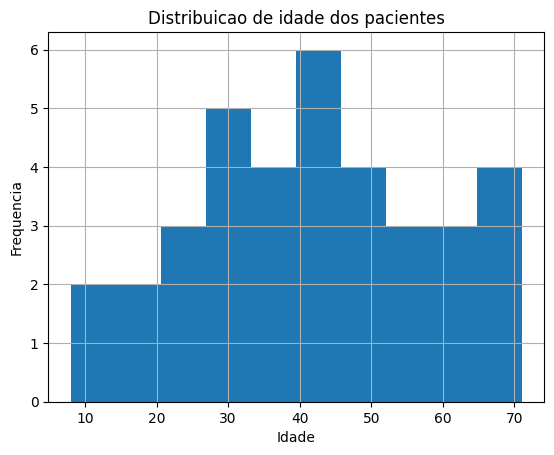

In [30]:
dados['IDADE'].hist()
plt.title('Distribuicao de idade dos pacientes')
plt.xlabel('Idade')
plt.ylabel('Frequencia')
plt.show()

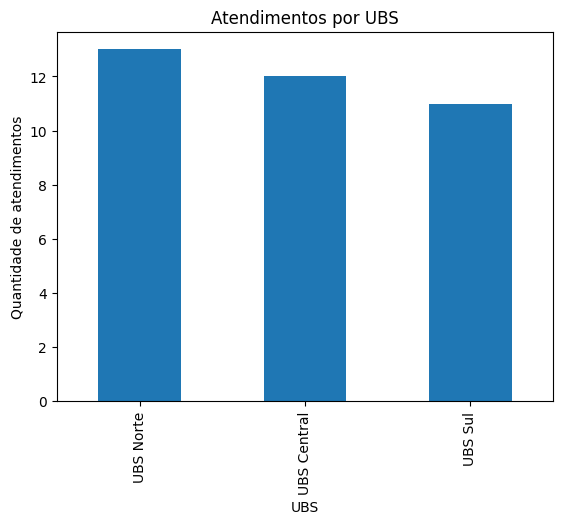

In [31]:
dados['UBS'].value_counts().plot.bar()
plt.title('Atendimentos por UBS')
plt.xlabel('UBS')
plt.ylabel('Quantidade de atendimentos')
plt.show()

## 7. Verificação Final e Exportação

In [32]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36 entries, 0 to 39
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   NOME            36 non-null     object        
 1   SEXO            36 non-null     object        
 2   IDADE           36 non-null     float64       
 3   PESO_KG         36 non-null     float64       
 4   UBS             36 non-null     object        
 5   DT_ATENDIMENTO  36 non-null     datetime64[ns]
 6   FAIXA_PESO      36 non-null     object        
 7   PESO_G          36 non-null     float64       
 8   FAIXA_ETARIA    36 non-null     category      
dtypes: category(1), datetime64[ns](1), float64(3), object(4)
memory usage: 2.7+ KB


In [33]:
dados.describe()

,IDADE,PESO_KG,DT_ATENDIMENTO,PESO_G
count,36.000000,36.000000,36,36.000000
mean,41.638889,67.297222,2026-03-11 04:00:00,67297.222222
min,8.000000,30.400000,2026-03-02 00:00:00,30400.000000
25%,29.750000,61.300000,2026-03-06 18:00:00,61300.000000
50%,41.500000,69.200000,2026-03-11 12:00:00,69200.000000
75%,53.500000,76.600000,2026-03-16 00:00:00,76600.000000
max,71.000000,95.600000,2026-03-20 00:00:00,95600.000000
std,16.863998,14.108933,NaN,14108.933059


In [34]:
dados.to_csv('pacientes_tratada.csv', index=False)
dados.to_excel('pacientes_tratada.xlsx', index=False)